# Détecteur de Tachyphémie — CNN sur Spectrogrammes

## Objectif
Ce notebook implémente un **détecteur de tachyphémie** (débit de parole anormalement rapide) à l'aide d'un **CNN (Convolutional Neural Network)** appliqué sur des **spectrogrammes Mel**.

La tachyphémie est un symptôme courant lors des **phases maniaques ou hypomaniaques** du trouble bipolaire : la personne parle très vite, les syllabes s'enchaînent rapidement, le tempo vocal augmente de façon anormale.

---

### Pipeline complet
```
Fichier Audio (.wav)
       │
       ▼
Spectrogramme Mel (image 2D)
       │
       ▼
 CNN (classification)
       │
       ▼
normal / tachyphemia
       │
       ▼
  Débit de parole (syllabes/sec)
       │
       ▼
 Score d'agitation (0–1)
```

---

### Pourquoi un CNN sur spectrogrammes ?
Un spectrogramme transforme le signal audio en **image 2D** (temps × fréquence).  
Un CNN est l'architecture idéale pour analyser des images : il détecte automatiquement les **patterns visuels** qui caractérisent un débit rapide (syllabes très denses, harmoniques rapprochées, transitions fréquentes).  
C'est plus puissant qu'une approche par features manuelles pour capturer la structure temporelle fine du signal.

---

| Paramètre | Valeur |
|---|---|
| Dataset | BD-Audio (ou RAVDESS simulé si BD-Audio indisponible) |
| Modèle | CNN (Conv2D + BatchNorm + MaxPool + Dense) |
| Entrée | Spectrogramme Mel 128 bandes × 128 frames |
| Sortie | normal / tachyphemia + débit (syl/sec) + score agitation |
| Framework | TensorFlow / Keras |


In [1]:
# =============================================================
# 1. INSTALLATION
# =============================================================
# Décommente si nécessaire
# !pip install librosa tensorflow scikit-learn matplotlib seaborn soundfile numpy pandas

In [2]:
# =============================================================
# 2. IMPORTS
# =============================================================
import os
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version :", tf.__version__)
print("GPU disponible :", tf.config.list_physical_devices('GPU'))

TensorFlow version : 2.20.0
GPU disponible : []


In [3]:
# =============================================================
# 3. CONFIGURATION GLOBALE
# =============================================================

# ─── Chemins ───────────────────────────────────────────────
# BD-Audio : remplace par ton chemin réel
# Si BD-Audio non disponible, on utilisera RAVDESS pour simuler
BD_AUDIO_DIR  = Path("C:/Users/LOQ/Desktop/testpi/DATASETS/BD-Audio")
RAVDESS_DIR   = Path("C:/Users/LOQ/Desktop/testpi/DATASETS/RAVDESS/Audio_Speech_Actors_01-24")

# ─── Spectrogramme ─────────────────────────────────────────
SAMPLE_RATE   = 22050       # Hz
DURATION      = 3.0         # secondes par extrait
N_MELS        = 128         # nombre de bandes Mel
N_FFT         = 2048        # taille de la fenêtre FFT
HOP_LENGTH    = 512         # pas entre deux fenêtres
IMG_HEIGHT    = 128         # hauteur image CNN
IMG_WIDTH     = 128         # largeur image CNN

# ─── Seuils tachyphémie ────────────────────────────────────
# Débit normal : 3–5 syllabes/sec | Tachyphémie : > 6 syllabes/sec
TACHYPHEMIA_TEMPO_THRESHOLD = 140  # BPM (proxy du débit de parole)

# ─── Entraînement ──────────────────────────────────────────
BATCH_SIZE    = 32
EPOCHS        = 40
LEARNING_RATE = 1e-3
VALIDATION_SPLIT = 0.2

print("Configuration chargée.")
print(f"Spectrogramme : {IMG_HEIGHT}×{IMG_WIDTH} px, {N_MELS} bandes Mel")
print(f"Durée par segment : {DURATION}s à {SAMPLE_RATE} Hz")
print(f"Seuil tachyphémie : tempo > {TACHYPHEMIA_TEMPO_THRESHOLD} BPM")

Configuration chargée.
Spectrogramme : 128×128 px, 128 bandes Mel
Durée par segment : 3.0s à 22050 Hz
Seuil tachyphémie : tempo > 140 BPM


In [4]:
# =============================================================
# 4. GÉNÉRATION DU SPECTROGRAMME MEL
# =============================================================
# C'est la pièce centrale du pipeline.
# On transforme chaque fichier audio en image 2D (temps × fréquence).

def compute_mel_spectrogram(file_path, sr=SAMPLE_RATE, duration=DURATION,
                             n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH,
                             img_h=IMG_HEIGHT, img_w=IMG_WIDTH):
    """
    Charge un fichier audio et retourne un spectrogramme Mel normalisé
    redimensionné à (img_h, img_w) prêt pour le CNN.

    Étapes :
    1. Chargement audio (librosa)
    2. Padding/truncation à durée fixe
    3. Calcul STFT puis Mel filterbank
    4. Conversion en dB (meilleure dynamique)
    5. Normalisation [0, 1]
    6. Resize vers (img_h, img_w)

    Returns
    -------
    np.ndarray shape (img_h, img_w, 1)  — canal unique (grayscale)
    """
    try:
        y, sr = librosa.load(file_path, sr=sr, duration=duration)

        # Padding si le fichier est plus court que DURATION
        target_len = int(sr * duration)
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)), mode="constant")
        else:
            y = y[:target_len]

        # Normalisation amplitude
        peak = np.max(np.abs(y))
        if peak > 0:
            y = y / peak

        # Spectrogramme Mel
        mel = librosa.feature.melspectrogram(
            y=y, sr=sr,
            n_mels=n_mels, n_fft=n_fft, hop_length=hop_length
        )

        # Conversion dB
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Normalisation [0, 1]
        mel_min, mel_max = mel_db.min(), mel_db.max()
        if mel_max - mel_min > 0:
            mel_norm = (mel_db - mel_min) / (mel_max - mel_min)
        else:
            mel_norm = mel_db

        # Resize vers (IMG_HEIGHT, IMG_WIDTH)
        import cv2  # OpenCV pour le resize
        mel_resized = cv2.resize(mel_norm, (img_w, img_h),
                                  interpolation=cv2.INTER_LINEAR)

        return mel_resized[..., np.newaxis].astype(np.float32)  # (H, W, 1)

    except Exception as e:
        print(f"Erreur sur {file_path}: {e}")
        return None


print("Fonction compute_mel_spectrogram() définie.")

Fonction compute_mel_spectrogram() définie.


In [5]:
# =============================================================
# 5. FALLBACK : SIMULATION AVEC RAVDESS
#    (si BD-Audio n'est pas disponible)
# =============================================================
# BD-Audio contient des enregistrements étiquetés tachyphémie vs normal.
# Si indisponible, on simule en utilisant RAVDESS :
#   - "angry" + "happy" = proxy haute énergie/débit → simulé tachyphemia
#   - "neutral" + "sad"                            → simulé normal
# C'est une APPROXIMATION pour validation du pipeline.

RAVDESS_EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

# Émotions proxy pour tachyphémie (débit élevé)
TACHYPHEMIA_PROXY  = {"angry", "happy", "surprised"}
NORMAL_PROXY       = {"neutral", "calm", "sad"}


def parse_ravdess_emotion(filename):
    parts = filename.split("-")
    if len(parts) < 3:
        return None
    return RAVDESS_EMOTION_MAP.get(parts[2], None)


def load_dataset(use_ravdess_fallback=True):
    """
    Charge le dataset BD-Audio ou bascule sur RAVDESS simulé.

    Returns
    -------
    X : np.ndarray (N, IMG_HEIGHT, IMG_WIDTH, 1)
    y : np.ndarray (N,)  labels binaires : 0=normal, 1=tachyphemia
    filepaths : list[str]
    """
    X, y, filepaths = [], [], []

    if BD_AUDIO_DIR.exists() and not use_ravdess_fallback:
        # ── Mode BD-Audio ──
        # Structure attendue :
        #   BD-Audio/
        #     normal/    *.wav
        #     tachyphemia/  *.wav
        for label_name, label_int in [("normal", 0), ("tachyphemia", 1)]:
            folder = BD_AUDIO_DIR / label_name
            if not folder.exists():
                print(f"[ATTENTION] Dossier manquant : {folder}")
                continue
            for wav in sorted(folder.glob("*.wav")):
                spec = compute_mel_spectrogram(wav)
                if spec is None:
                    continue
                X.append(spec)
                y.append(label_int)
                filepaths.append(str(wav))
        source = "BD-Audio"

    else:
        # ── Mode RAVDESS fallback ──
        print("BD-Audio non trouvé → utilisation de RAVDESS (simulation)")
        for actor_dir in sorted(RAVDESS_DIR.glob("Actor_*")):
            for wav in sorted(actor_dir.glob("*.wav")):
                emotion = parse_ravdess_emotion(wav.name)
                if emotion in TACHYPHEMIA_PROXY:
                    label_int = 1
                elif emotion in NORMAL_PROXY:
                    label_int = 0
                else:
                    continue
                spec = compute_mel_spectrogram(wav)
                if spec is None:
                    continue
                X.append(spec)
                y.append(label_int)
                filepaths.append(str(wav))
        source = "RAVDESS (simulation)"

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)
    print(f"Dataset chargé depuis {source}")
    print(f"Total : {len(X)} samples | normal={np.sum(y==0)} | tachyphemia={np.sum(y==1)}")
    return X, y, filepaths

Chargement du dataset...
BD-Audio non trouvé → utilisation de RAVDESS (simulation)
Dataset chargé depuis RAVDESS (simulation)
Total : 1056 samples | normal=480 | tachyphemia=576

Shape X : (1056, 128, 128, 1)
Shape y : (1056,)
Distribution : {np.int32(0): np.int64(480), np.int32(1): np.int64(576)}


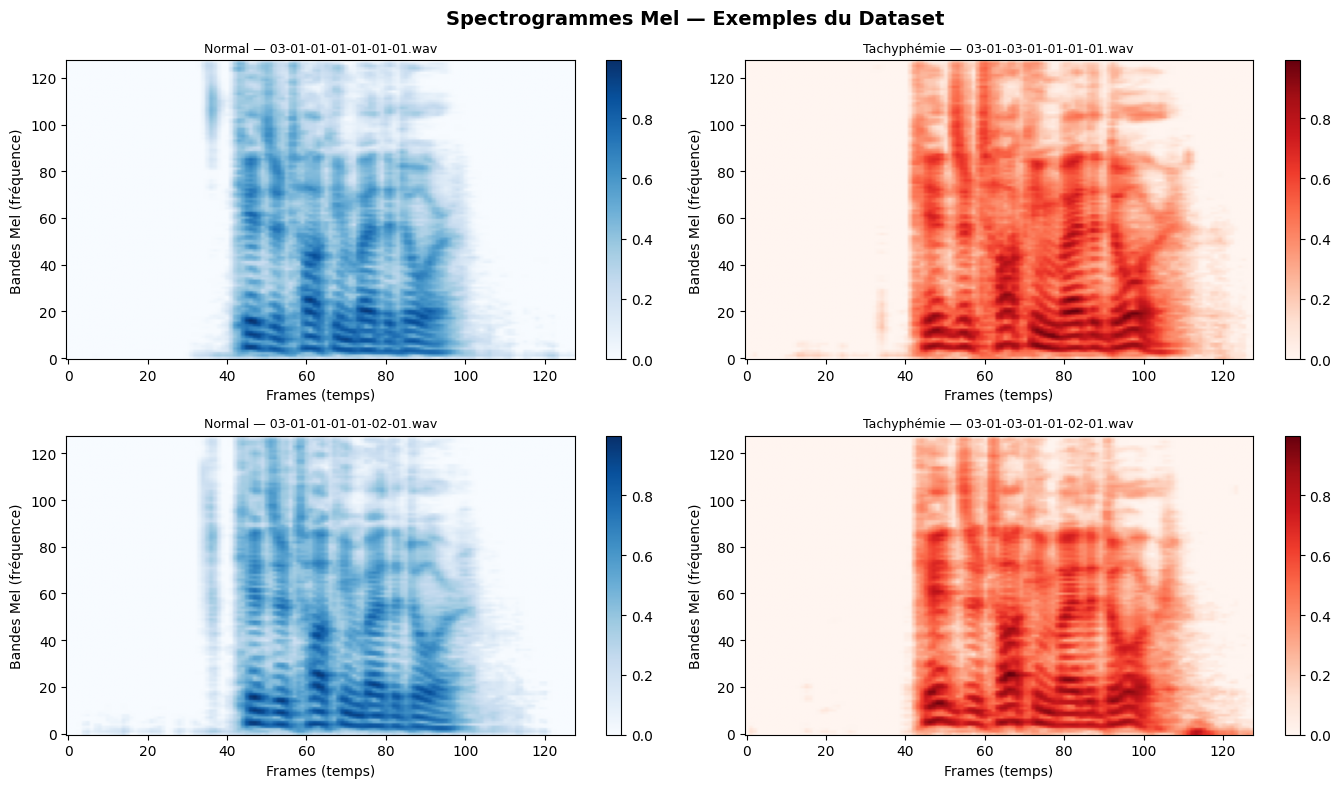

Les spectrogrammes de tachyphémie ont typiquement des transitions plus denses et rapprochées.


In [6]:
# =============================================================
# 6. CHARGEMENT ET VISUALISATION DES SPECTROGRAMMES
# =============================================================
print("Chargement du dataset...")
X, y, filepaths = load_dataset(use_ravdess_fallback=True)

print(f"\nShape X : {X.shape}")
print(f"Shape y : {y.shape}")
print(f"Distribution : {dict(zip(*np.unique(y, return_counts=True)))}")

# ── Visualisation : 4 spectrogrammes (2 normal + 2 tachyphemia) ──
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Spectrogrammes Mel — Exemples du Dataset", fontsize=14, fontweight='bold')

label_names = {0: "Normal", 1: "Tachyphémie"}
colors_map  = {0: "Blues", 1: "Reds"}

shown = {0: 0, 1: 0}
plot_idx = 0

for i, (spec, label) in enumerate(zip(X, y)):
    if shown[label] < 2:
        row, col = shown[label] if label == 0 else shown[label], label
        ax = axes[shown[label]][label]
        im = ax.imshow(spec[:, :, 0], aspect="auto", origin="lower",
                       cmap=colors_map[label])
        ax.set_title(f"{label_names[label]} — {Path(filepaths[i]).name[:30]}",
                     fontsize=9)
        ax.set_xlabel("Frames (temps)")
        ax.set_ylabel("Bandes Mel (fréquence)")
        plt.colorbar(im, ax=ax, format="%.1f")
        shown[label] += 1
    if all(v >= 2 for v in shown.values()):
        break

plt.tight_layout()
plt.show()
print("Les spectrogrammes de tachyphémie ont typiquement des transitions plus denses et rapprochées.")

In [7]:
# =============================================================
# 7. PRÉPARATION DES DONNÉES (SPLIT TRAIN / VAL / TEST)
# =============================================================

# Split stratifié : 70% train / 15% val / 15% test
X_trainval, X_test, y_trainval, y_test, fp_trainval, fp_test = train_test_split(
    X, y, filepaths,
    test_size=0.15,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.176,   # 0.176 × 0.85 ≈ 0.15 du total
    stratify=y_trainval,
    random_state=42
)

print(f"Train : {X_train.shape}   normal={np.sum(y_train==0)} | tachy={np.sum(y_train==1)}")
print(f"Val   : {X_val.shape}   normal={np.sum(y_val==0)} | tachy={np.sum(y_val==1)}")
print(f"Test  : {X_test.shape}   normal={np.sum(y_test==0)} | tachy={np.sum(y_test==1)}")

# Data augmentation légère sur train (bruit gaussien + time shift)
def augment_spectrogram(spec, noise_factor=0.005):
    """Ajoute un léger bruit gaussien pour régulariser."""
    noise = np.random.normal(0, noise_factor, spec.shape).astype(np.float32)
    return np.clip(spec + noise, 0.0, 1.0)

# Augmenter uniquement les tachyphémies si déséquilibre
tachy_idx = np.where(y_train == 1)[0]
normal_idx = np.where(y_train == 0)[0]

if len(normal_idx) > 1.5 * len(tachy_idx):
    print("\nDéséquilibre détecté — augmentation des tachyphémies...")
    augmented_X = np.array([augment_spectrogram(X_train[i]) for i in tachy_idx])
    augmented_y = np.ones(len(tachy_idx), dtype=np.int32)
    X_train = np.concatenate([X_train, augmented_X])
    y_train = np.concatenate([y_train, augmented_y])
    print(f"Après augmentation → Train : {X_train.shape}")

print("\nDonnées prêtes pour l'entraînement.")

Train : (739, 128, 128, 1)   normal=336 | tachy=403
Val   : (158, 128, 128, 1)   normal=72 | tachy=86
Test  : (159, 128, 128, 1)   normal=72 | tachy=87

Données prêtes pour l'entraînement.


In [8]:
# =============================================================
# 8. ARCHITECTURE CNN
# =============================================================
# Architecture : VGG-like léger adapté aux spectrogrammes
#
# Blocs Conv2D + BatchNorm + ReLU + MaxPool
# → chaque bloc double les filtres, réduit la résolution de ×2
# → GlobalAveragePooling remplace Flatten (plus robuste au surapprentissage)
# → Dropout fort (0.5) avant la couche Dense finale

def build_cnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, 1), learning_rate=LEARNING_RATE):
    """
    Construit et compile le CNN pour la classification binaire
    normal vs tachyphemia.

    Architecture :
        Input (128×128×1)
        ├── Bloc 1 : Conv2D(32) × 2 + BN + ReLU + MaxPool(2×2) → 64×64×32
        ├── Bloc 2 : Conv2D(64) × 2 + BN + ReLU + MaxPool(2×2) → 32×32×64
        ├── Bloc 3 : Conv2D(128) × 2 + BN + ReLU + MaxPool(2×2) → 16×16×128
        ├── Bloc 4 : Conv2D(256) + BN + ReLU + MaxPool(2×2) → 8×8×256
        ├── GlobalAveragePooling2D → 256
        ├── Dense(256) + ReLU + Dropout(0.5)
        └── Dense(1) + Sigmoid → probabilité tachyphémie
    """
    inp = keras.Input(shape=input_shape, name="spectrogram_input")

    # ── Bloc 1 ──
    x = layers.Conv2D(32, (3, 3), padding="same", name="conv1a")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(32, (3, 3), padding="same", name="conv1b")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.1)(x)

    # ── Bloc 2 ──
    x = layers.Conv2D(64, (3, 3), padding="same", name="conv2a")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, (3, 3), padding="same", name="conv2b")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    # ── Bloc 3 ──
    x = layers.Conv2D(128, (3, 3), padding="same", name="conv3a")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(128, (3, 3), padding="same", name="conv3b")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # ── Bloc 4 ──
    x = layers.Conv2D(256, (3, 3), padding="same", name="conv4")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # ── Tête de classification ──
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu", name="dense1")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = keras.Model(inputs=inp, outputs=out, name="TachyphoemiaCNN")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall")
        ]
    )
    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "TachyphoemiaCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spectrogram_input (InputLayer)  │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1a (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1b (Conv2D)                 │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2a (Conv2D)                 │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv2D)                 │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3a (Conv2D)                 │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3b (Conv2D)                 │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 650,465 (2.48 MB)

 Trainable params: 649,057 (2.48 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [25]:
# =============================================================
# 9. ENTRAÎNEMENT
# =============================================================

# Callbacks
cb_early_stop = callbacks.EarlyStopping(
    monitor="val_auc",
    patience=8,
    restore_best_weights=True,
    mode="max",
    verbose=1
)

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

cb_checkpoint = callbacks.ModelCheckpoint(
    "best_tachyphemia_cnn.keras",
    monitor="val_auc",
    save_best_only=True,
    mode="max",
    verbose=1
)

# Poids de classe pour compenser le déséquilibre éventuel
n_normal  = np.sum(y_train == 0)
n_tachy   = np.sum(y_train == 1)
total     = n_normal + n_tachy
class_weight = {0: total / (2 * n_normal), 1: total / (2 * n_tachy)}

# Boost léger sur la classe Tachyphémie pour réduire les faux négatifs
tachy_weight_boost = 1.4
class_weight[1] *= tachy_weight_boost

print("Poids de classe :", class_weight)
print("Boost tachyphémie :", tachy_weight_boost)

print("\nDébut de l'entraînement...")
history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[cb_early_stop, cb_reduce_lr, cb_checkpoint],
    verbose=1
)

print("\nEntraînement terminé.")

Poids de classe : {0: np.float64(1.099702380952381), 1: np.float64(1.2836228287841192)}
Boost tachyphémie : 1.4

Début de l'entraînement...
Epoch 1/40
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.8781 - auc: 0.9543 - loss: 0.3222 - precision: 0.8766 - recall: 0.9026
Epoch 1: val_auc improved from None to 0.51437, saving model to best_tachyphemia_cnn.keras

Epoch 1: finished saving model to best_tachyphemia_cnn.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 409ms/step - accuracy: 0.8782 - auc: 0.9557 - loss: 0.3217 - precision: 0.8808 - recall: 0.8983 - val_accuracy: 0.4557 - val_auc: 0.5144 - val_loss: 1.1246 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 2.5000e-04
Epoch 2/40
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9147 - auc: 0.9675 - loss: 0.2823 - precision: 0.9236 - recall: 0.9176
Epoch 2: val_auc did not improve from 0.51437
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 393ms/step - accuracy: 0.9080 - auc: 0.9651 - loss: 0.2887 - precision: 0.9156 - recall: 

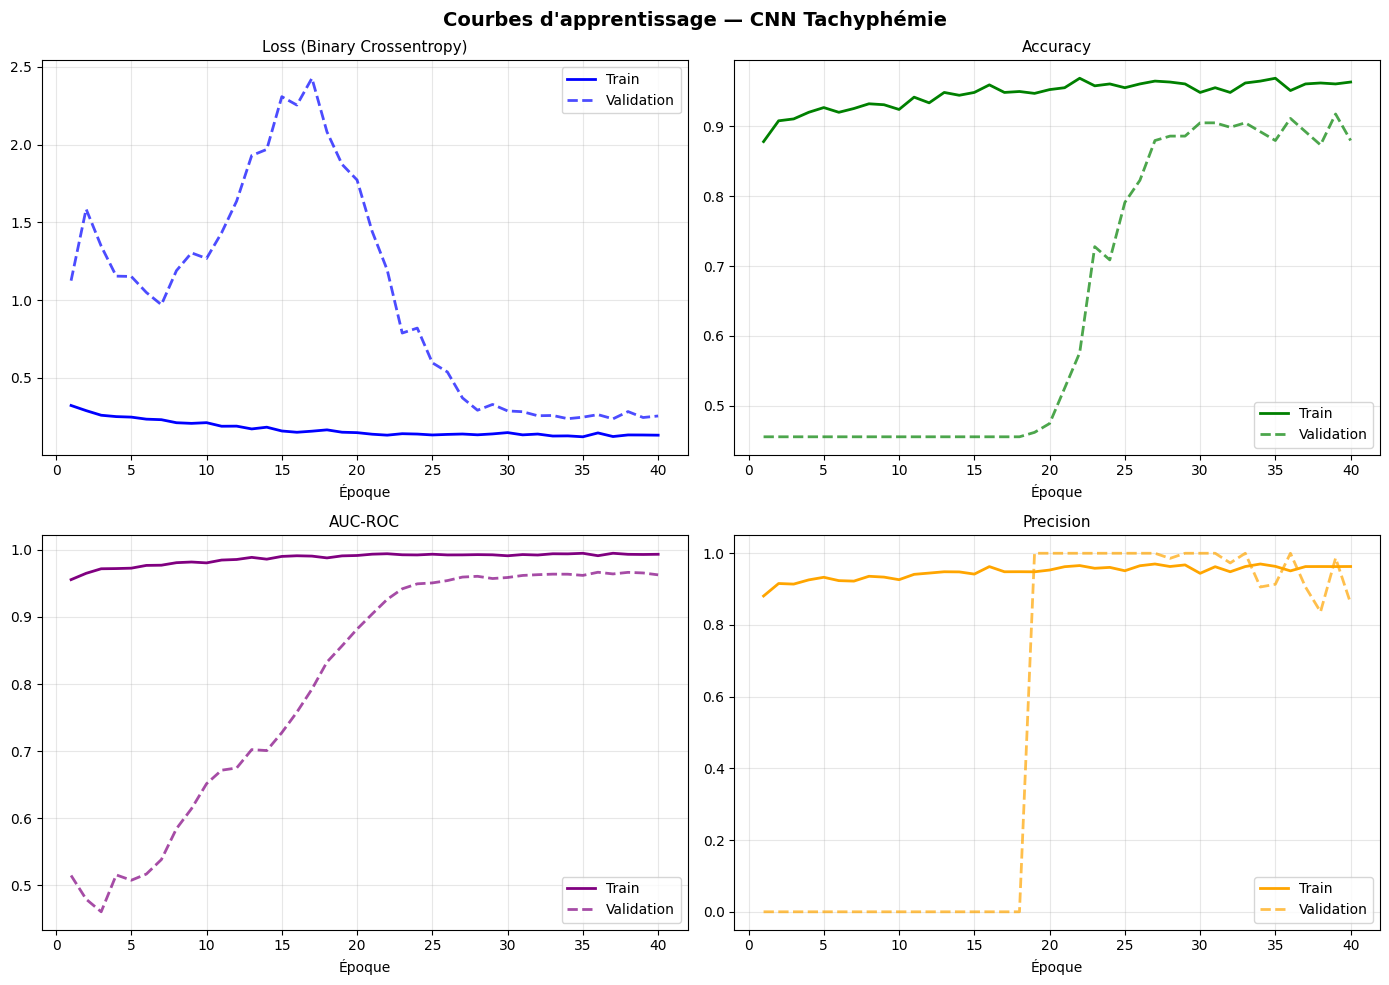

In [26]:
# =============================================================
# 10. COURBES D'APPRENTISSAGE
# =============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Courbes d'apprentissage — CNN Tachyphémie", fontsize=14, fontweight='bold')

metrics_to_plot = [
    ("loss",      "Loss (Binary Crossentropy)", "blue"),
    ("accuracy",  "Accuracy",                    "green"),
    ("auc",       "AUC-ROC",                      "purple"),
    ("precision", "Precision",                    "orange"),
]

for ax, (metric, title, color) in zip(axes.flat, metrics_to_plot):
    train_vals = history.history.get(metric, [])
    val_vals   = history.history.get(f"val_{metric}", [])
    epochs_range = range(1, len(train_vals) + 1)

    ax.plot(epochs_range, train_vals, color=color, label="Train", linewidth=2)
    ax.plot(epochs_range, val_vals, color=color, linestyle="--",
            label="Validation", linewidth=2, alpha=0.7)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Époque")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# =============================================================
# 11. ÉVALUATION SUR LE JEU DE TEST
# =============================================================

print("Évaluation sur le test set...")
test_results = cnn_model.evaluate(X_test, y_test, verbose=0)
metric_names = cnn_model.metrics_names

print("\n── Métriques Test ──")
for name, val in zip(metric_names, test_results):
    print(f"  {name:12s}: {val:.4f}")

# ── Seuil optimisé sur la validation (cible TPR>=0.60 et TNR≈0.60) ──
val_prob = cnn_model.predict(X_val, verbose=0).ravel()
thresholds = np.linspace(0.05, 0.95, 181)
target_tpr = 0.60
target_tnr = 0.60
best_threshold = 0.5
best_score = float("inf")
best_tpr = 0.0
best_tnr = 0.0
found = False

for t in thresholds:
    val_pred = (val_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, val_pred).ravel()
    tpr = tp / (tp + fn + 1e-8)
    tnr = tn / (tn + fp + 1e-8)
    if tpr >= target_tpr:
        score = abs(tnr - target_tnr)
        if score < best_score:
            best_score = score
            best_threshold = float(t)
            best_tpr = float(tpr)
            best_tnr = float(tnr)
            found = True

if not found:
    for t in thresholds:
        val_pred = (val_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, val_pred).ravel()
        tpr = tp / (tp + fn + 1e-8)
        tnr = tn / (tn + fp + 1e-8)
        score = (tpr - target_tpr) ** 2 + (tnr - target_tnr) ** 2
        if score < best_score:
            best_score = score
            best_threshold = float(t)
            best_tpr = float(tpr)
            best_tnr = float(tnr)

print(
    f"\nSeuil optimal (TPR>=0.60) : {best_threshold:.3f} "
    f"| TPR(tachy)={best_tpr:.3f} | TNR(normal)={best_tnr:.3f}"
)

# Prédictions
y_prob = cnn_model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= best_threshold).astype(int)

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred,
                             target_names=["Normal", "Tachyphémie"]))

# AUC-ROC
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC : {auc_score:.4f}")

Évaluation sur le test set...

── Métriques Test ──
  loss        : 0.1975
  compile_metrics: 0.9245

Seuil optimal (TPR>=0.60) : 0.050 | TPR(tachy)=0.953 | TNR(normal)=0.667

── Classification Report ──
              precision    recall  f1-score   support

      Normal       0.98      0.75      0.85        72
 Tachyphémie       0.83      0.99      0.90        87

    accuracy                           0.88       159
   macro avg       0.90      0.87      0.88       159
weighted avg       0.90      0.88      0.88       159

AUC-ROC : 0.9847


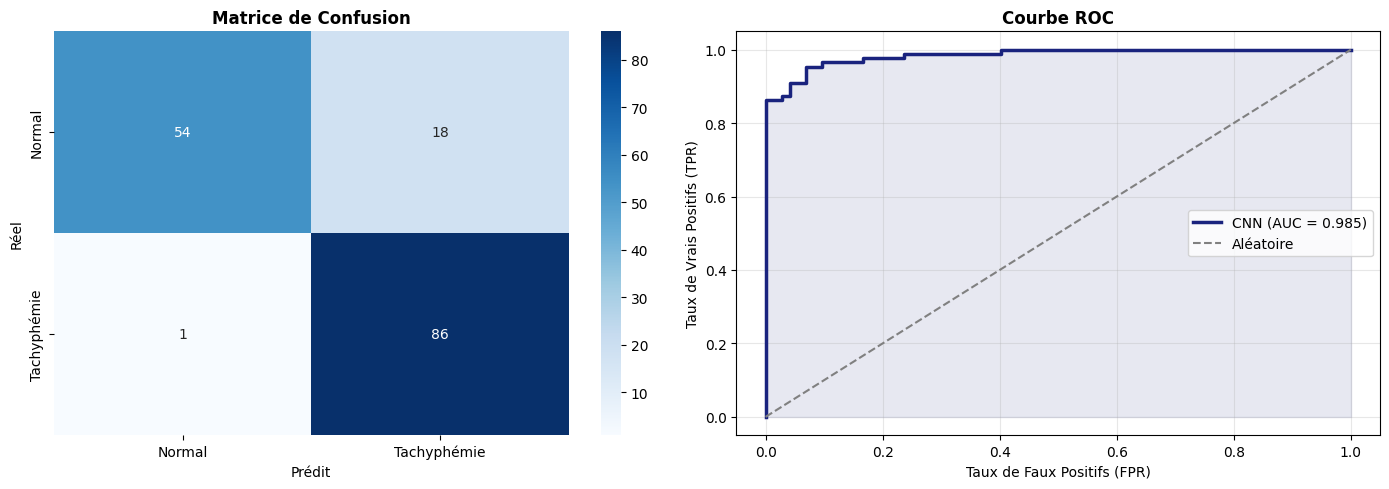

In [28]:
# ============================================================
# 12. MATRICE DE CONFUSION + COURBE ROC
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Matrice de confusion ──
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Normal", "Tachyphémie"],
    yticklabels=["Normal", "Tachyphémie"],
    ax=axes[0]
)
axes[0].set_title("Matrice de Confusion", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Réel")

# ── Courbe ROC ──
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color="#1a237e", linewidth=2.5,
             label=f"CNN (AUC = {auc_score:.3f})")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Aléatoire")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#1a237e")
axes[1].set_title("Courbe ROC", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Taux de Faux Positifs (FPR)")
axes[1].set_ylabel("Taux de Vrais Positifs (TPR)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# =============================================================
# 13. CALCUL DU DÉBIT DE PAROLE (syllabes/sec)
# =============================================================
# Méthode : détection des onsets (débuts de syllabes) via l'enveloppe d'onset.
#
# Principe :
#   1. On calcule l'enveloppe d'onset (force des transitions énergétiques)
#   2. On détecte les pics = débuts de syllabes approximatifs
#   3. speech_rate = nb_syllabes / durée_parole

def estimate_speech_rate(file_path, sr=SAMPLE_RATE, duration=DURATION):
    """
    Estime le débit de parole en syllabes/seconde.

    Returns
    -------
    dict avec :
      - speech_rate_syl_per_sec : float
      - n_onsets                : int  (nombre de syllabes estimées)
      - tempo_bpm               : float
      - is_tachyphemia          : bool
      - agitation_score         : float in [0, 1]
    """
    y, sr = librosa.load(file_path, sr=sr, duration=duration)

    # Enveloppe d'onset
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)

    # Détection des onsets (débuts de syllabes)
    onsets = librosa.onset.onset_detect(
        onset_envelope=onset_env, sr=sr,
        hop_length=HOP_LENGTH,
        backtrack=True
    )
    n_onsets = len(onsets)

    # Durée réelle du signal
    actual_duration = len(y) / sr
    speech_rate = n_onsets / actual_duration if actual_duration > 0 else 0.0

    # Tempo
    tempo = float(np.mean(
        librosa.feature.tempo(onset_envelope=onset_env, sr=sr)
    ))

    # Score d'agitation [0, 1] : normalisé sur [0, 8 syl/sec]
    agitation_score = min(speech_rate / 8.0, 1.0)

    # Seuil tachyphémie : > 6 syllabes/sec OU tempo > 140 BPM
    is_tachyphemia = (speech_rate > 6.0) or (tempo > TACHYPHEMIA_TEMPO_THRESHOLD)

    return {
        "speech_rate_syl_per_sec": round(speech_rate, 3),
        "n_onsets":                n_onsets,
        "tempo_bpm":               round(tempo, 2),
        "is_tachyphemia":          is_tachyphemia,
        "agitation_score":         round(agitation_score, 4),
    }


print("Fonction estimate_speech_rate() définie.")
print("\nSeuils de référence :")
print("  Parole normale  : 3–5 syllabes/sec")
print("  Parole rapide   : 5–6 syllabes/sec")
print("  Tachyphémie     : > 6 syllabes/sec")

Fonction estimate_speech_rate() définie.

Seuils de référence :
  Parole normale  : 3–5 syllabes/sec
  Parole rapide   : 5–6 syllabes/sec
  Tachyphémie     : > 6 syllabes/sec


In [30]:
# =============================================================
# 14. FONCTION DE PRÉDICTION COMPLÈTE
# =============================================================
# Pipeline final : un fichier audio → prédiction CNN + débit + score agitation

def predict_tachyphemia(file_path):
    """
    Pipeline complet de détection de tachyphémie.

    1. Génère le spectrogramme Mel
    2. Passe dans le CNN → probabilité tachyphémie
    3. Estime le débit de parole (syllabes/sec)
    4. Calcule le score d'agitation final (fusion CNN + débit)
    5. Génère l'interprétation clinique (non-diagnostique)

    Returns
    -------
    dict complet
    """
    file_path = Path(file_path)
    if not file_path.exists():
        return {"error": f"Fichier introuvable : {file_path}"}

    # ── Spectrogramme → CNN ──
    spec = compute_mel_spectrogram(file_path)
    if spec is None:
        return {"error": "Impossible de calculer le spectrogramme."}

    spec_batch = spec[np.newaxis, ...]  # (1, H, W, 1)
    cnn_prob = float(cnn_model.predict(spec_batch, verbose=0)[0, 0])
    cnn_label = "tachyphemia" if cnn_prob >= 0.5 else "normal"

    # ── Débit de parole ──
    speech_info = estimate_speech_rate(file_path)

    # ── Score d'agitation fusionné (CNN + débit) ──
    # Pondération : 60% CNN, 40% débit
    fused_score = 0.6 * cnn_prob + 0.4 * speech_info["agitation_score"]
    fused_score = round(min(fused_score, 1.0), 4)

    # ── Interprétation clinique ──
    if fused_score >= 0.7:
        clinical_note = (
            "Signal vocal compatible avec une tachyphémie marquée. "
            "Débit rapide détecté — possible indicateur d'agitation ou de phase maniaque. "
            "Monitoring recommandé (non-diagnostique)."
        )
    elif fused_score >= 0.45:
        clinical_note = (
            "Signal vocal légèrement accéléré. "
            "À surveiller sur plusieurs observations avant interprétation. "
            "Monitoring recommandé (non-diagnostique)."
        )
    else:
        clinical_note = (
            "Débit de parole dans la plage normale. "
            "Aucun signal de tachyphémie sur cet enregistrement (non-diagnostique)."
        )

    return {
        "file":                    str(file_path.name),
        "cnn_probability":         round(cnn_prob, 4),
        "cnn_label":               cnn_label,
        "speech_rate_syl_per_sec": speech_info["speech_rate_syl_per_sec"],
        "n_onsets":                speech_info["n_onsets"],
        "tempo_bpm":               speech_info["tempo_bpm"],
        "is_tachyphemia_rule":     speech_info["is_tachyphemia"],
        "agitation_score_cnn":     round(cnn_prob, 4),
        "agitation_score_fused":   fused_score,
        "clinical_note":           clinical_note,
    }


print("Fonction predict_tachyphemia() définie.")

Fonction predict_tachyphemia() définie.


In [35]:
# =============================================================
# 15. TEST SUR UN FICHIER AUDIO
# =============================================================

# Test sur un fichier du jeu de test
test_fp = fp_test[1]
print("Fichier testé :", Path(test_fp).name)
print("Vrai label    :", "Tachyphémie" if y_test[1] == 1 else "Normal")

result = predict_tachyphemia(test_fp)

print("\n── Résultats ──")
for k, v in result.items():
    if k != "clinical_note":
        print(f"  {k:30s}: {v}")
print(f"\n  {'clinical_note':30s}:")
print(f"  {result['clinical_note']}")

Fichier testé : 03-01-03-02-01-02-15.wav
Vrai label    : Tachyphémie

── Résultats ──
  file                          : 03-01-03-02-01-02-15.wav
  cnn_probability               : 0.7488
  cnn_label                     : tachyphemia
  speech_rate_syl_per_sec       : 3.333
  n_onsets                      : 10
  tempo_bpm                     : 136.0
  is_tachyphemia_rule           : False
  agitation_score_cnn           : 0.7488
  agitation_score_fused         : 0.616

  clinical_note                 :
  Signal vocal légèrement accéléré. À surveiller sur plusieurs observations avant interprétation. Monitoring recommandé (non-diagnostique).


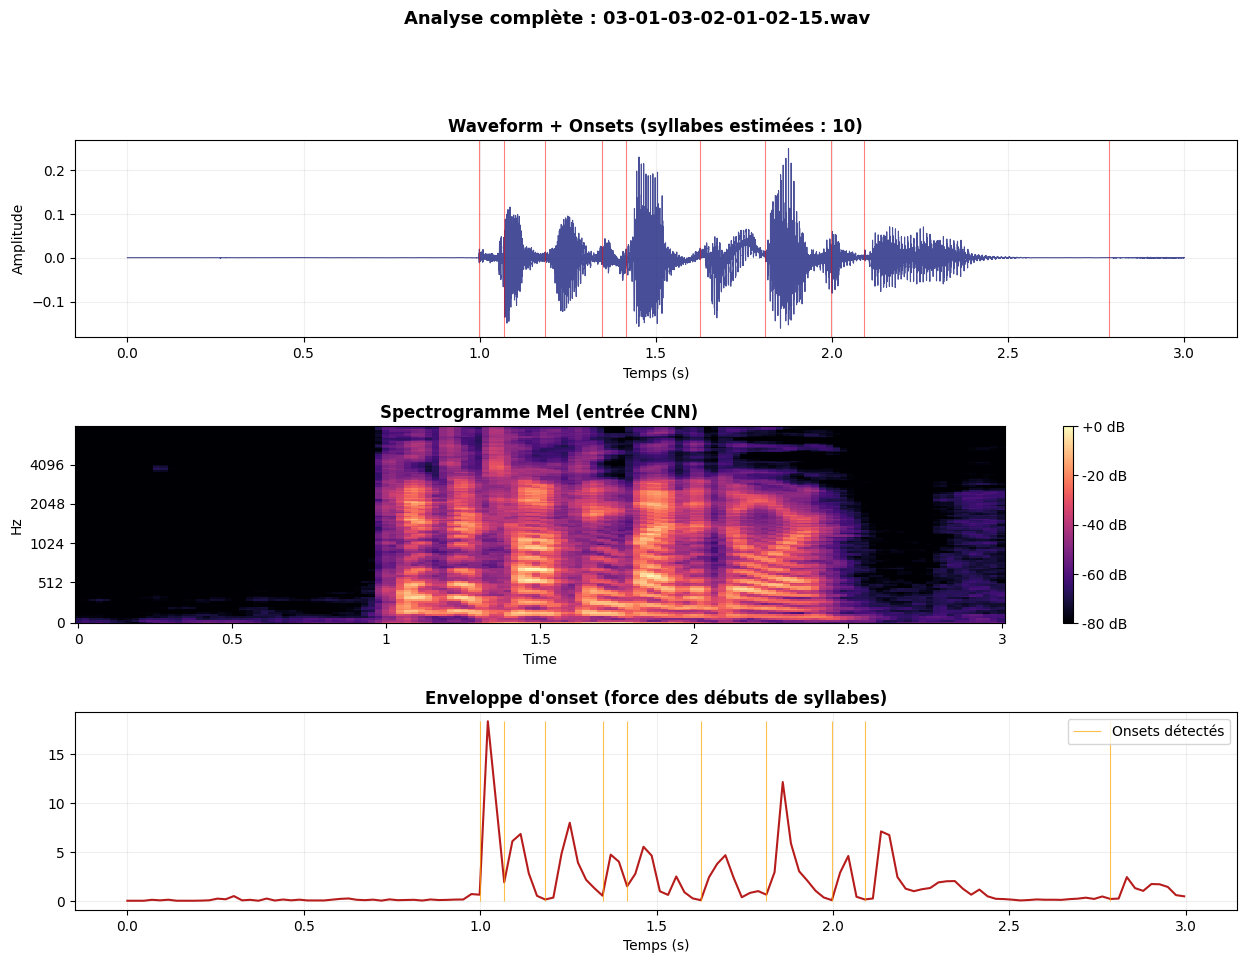

In [36]:
# =============================================================
# 16. VISUALISATION COMPLÈTE D'UN FICHIER
# =============================================================
# Affiche : waveform + spectrogramme Mel + enveloppe d'onset + onsets

def visualize_audio_full(file_path, sr=SAMPLE_RATE, duration=DURATION):
    y, sr = librosa.load(file_path, sr=sr, duration=duration)
    time_axis = np.linspace(0, len(y)/sr, len(y))

    # Spectrogramme Mel
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Onset envelope + onsets
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=HOP_LENGTH)
    onsets = librosa.onset.onset_detect(
        onset_envelope=onset_env, sr=sr,
        hop_length=HOP_LENGTH, backtrack=True
    )
    onset_times = librosa.frames_to_time(onsets, sr=sr, hop_length=HOP_LENGTH)

    fig = plt.figure(figsize=(15, 10))
    gs  = gridspec.GridSpec(3, 1, hspace=0.45)

    # ── Waveform + onsets ──
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(time_axis, y, color="#1a237e", linewidth=0.8, alpha=0.8)
    for ot in onset_times:
        ax1.axvline(x=ot, color="red", alpha=0.5, linewidth=0.8)
    ax1.set_title(f"Waveform + Onsets (syllabes estimées : {len(onsets)})",
                  fontweight='bold')
    ax1.set_xlabel("Temps (s)")
    ax1.set_ylabel("Amplitude")
    ax1.grid(alpha=0.2)

    # ── Spectrogramme Mel ──
    ax2 = fig.add_subplot(gs[1])
    img = librosa.display.specshow(
        mel_db, sr=sr, hop_length=HOP_LENGTH,
        x_axis="time", y_axis="mel",
        fmax=8000, ax=ax2, cmap="magma"
    )
    fig.colorbar(img, ax=ax2, format="%+2.0f dB")
    ax2.set_title("Spectrogramme Mel (entrée CNN)", fontweight='bold')

    # ── Onset envelope ──
    ax3 = fig.add_subplot(gs[2])
    onset_times_full = librosa.times_like(onset_env, sr=sr, hop_length=HOP_LENGTH)
    ax3.plot(onset_times_full, onset_env, color="#b71c1c", linewidth=1.5)
    ax3.vlines(onset_times, 0, onset_env.max(), color="orange",
               alpha=0.7, linewidth=0.8, label="Onsets détectés")
    ax3.set_title("Enveloppe d'onset (force des débuts de syllabes)", fontweight='bold')
    ax3.set_xlabel("Temps (s)")
    ax3.legend()
    ax3.grid(alpha=0.2)

    plt.suptitle(f"Analyse complète : {Path(file_path).name}",
                 fontsize=13, fontweight='bold', y=1.01)
    plt.show()


visualize_audio_full(test_fp)

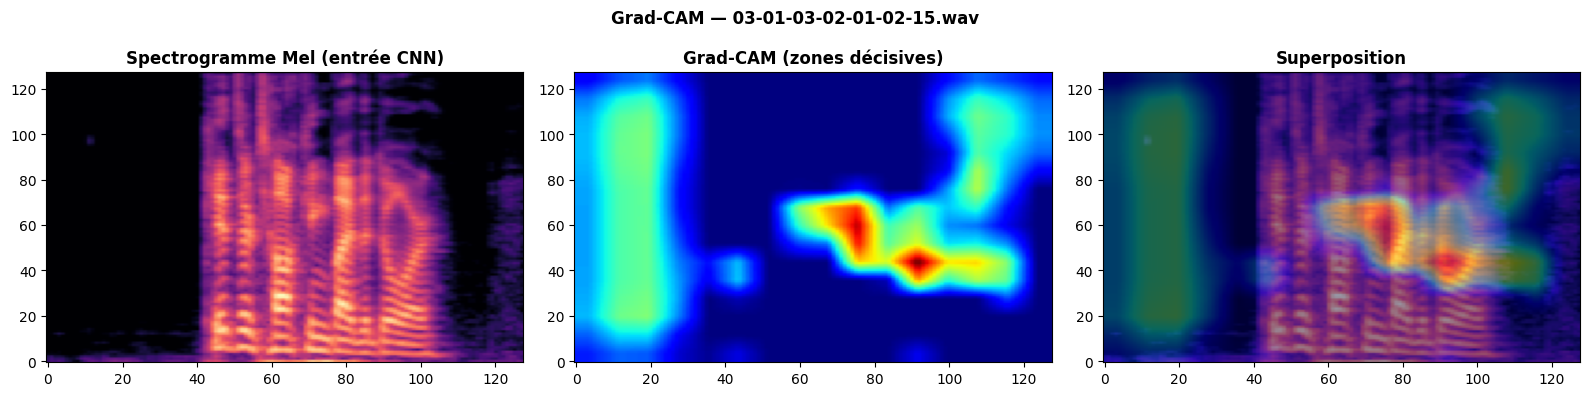

Les zones rouge/jaune = régions du spectrogramme importantes pour la décision du CNN.


In [37]:
# =============================================================
# 17. VISUALISATION GRAD-CAM (Explainability)
# =============================================================
# Grad-CAM : montre QUELLES zones du spectrogramme le CNN regarde
# pour décider si c'est de la tachyphémie.
# Zones chaudes = zones importantes pour la décision.

import tensorflow as tf

def grad_cam(model, img_array, layer_name="conv4"):
    """
    Calcule la carte d'activation Grad-CAM pour une image.

    Paramètres
    ----------
    model      : modèle Keras
    img_array  : np.ndarray (1, H, W, 1)
    layer_name : dernière couche conv à visualiser

    Returns
    -------
    heatmap : np.ndarray (H, W) normalisé [0, 1]
    """
    grad_model = tf.keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        inputs = tf.cast(img_array, tf.float32)
        conv_outputs, predictions = grad_model(inputs)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.nn.relu(heatmap).numpy()

    if heatmap.max() > 0:
        heatmap /= heatmap.max()

    return heatmap


# Applique Grad-CAM sur le fichier de test
spec_test = compute_mel_spectrogram(test_fp)
spec_batch = spec_test[np.newaxis, ...]

heatmap = grad_cam(cnn_model, spec_batch, layer_name="conv4")

import cv2
heatmap_resized = cv2.resize(heatmap, (IMG_WIDTH, IMG_HEIGHT))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].imshow(spec_test[:, :, 0], aspect="auto", origin="lower", cmap="magma")
axes[0].set_title("Spectrogramme Mel (entrée CNN)", fontweight='bold')

axes[1].imshow(heatmap_resized, aspect="auto", origin="lower", cmap="jet")
axes[1].set_title("Grad-CAM (zones décisives)", fontweight='bold')

# Superposition
spec_rgb = plt.cm.magma(spec_test[:, :, 0])[:, :, :3]
heatmap_rgb = plt.cm.jet(heatmap_resized)[:, :, :3]
overlay = 0.6 * spec_rgb + 0.4 * heatmap_rgb
axes[2].imshow(overlay, aspect="auto", origin="lower")
axes[2].set_title("Superposition", fontweight='bold')

plt.suptitle(f"Grad-CAM — {Path(test_fp).name}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("Les zones rouge/jaune = régions du spectrogramme importantes pour la décision du CNN.")

In [38]:
# =============================================================
# 18. TEST SUR PLUSIEURS FICHIERS — TABLEAU RÉCAPITULATIF
# =============================================================

n_samples = min(10, len(fp_test))
sample_indices = random.sample(range(len(fp_test)), n_samples)

rows = []
for idx in sample_indices:
    fp = fp_test[idx]
    true_label = "Tachyphémie" if y_test[idx] == 1 else "Normal"
    res = predict_tachyphemia(fp)
    rows.append({
        "Fichier":           Path(fp).name[:35],
        "Vrai label":        true_label,
        "CNN prédit":        res["cnn_label"],
        "CNN prob":          f"{res['cnn_probability']:.3f}",
        "Débit (syl/s)":     f"{res['speech_rate_syl_per_sec']:.2f}",
        "Tempo (BPM)":       f"{res['tempo_bpm']:.1f}",
        "Score agitation":   f"{res['agitation_score_fused']:.3f}",
        "Correct ?":         "✓" if res["cnn_label"] == ("tachyphemia" if y_test[idx]==1 else "normal") else "✗",
    })

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

                 Fichier  Vrai label  CNN prédit CNN prob Débit (syl/s) Tempo (BPM) Score agitation Correct ?
03-01-01-01-01-01-09.wav      Normal      normal    0.211          3.33       161.5           0.293         ✓
03-01-08-01-02-02-12.wav Tachyphémie tachyphemia    0.999          3.00       103.4           0.749         ✓
03-01-04-01-01-02-15.wav      Normal      normal    0.003          3.67       152.0           0.185         ✓
03-01-02-02-01-02-08.wav      Normal      normal    0.003          3.33       136.0           0.168         ✓
03-01-05-02-01-02-03.wav Tachyphémie tachyphemia    0.972          3.67       136.0           0.766         ✓
03-01-01-01-01-01-05.wav      Normal      normal    0.014          3.33       107.7           0.175         ✓
03-01-04-02-02-01-03.wav      Normal      normal    0.110          3.67       172.3           0.249         ✓
03-01-08-02-02-01-23.wav Tachyphémie tachyphemia    0.998          2.00       129.2           0.699         ✓
03-01-08-0

In [39]:
# =============================================================
# 19. TESTER SA PROPRE VOIX
# =============================================================
# Enregistre un fichier .wav avec ton téléphone ou Windows,
# puis remplace MY_AUDIO par son chemin.

MY_AUDIO = None  # ex: "ma_voix.wav"

if MY_AUDIO is not None and Path(MY_AUDIO).exists():
    print(f"Analyse de : {MY_AUDIO}")
    result = predict_tachyphemia(MY_AUDIO)

    print("\n── Résultats ──")
    for k, v in result.items():
        if k != "clinical_note":
            print(f"  {k:30s}: {v}")
    print(f"\n  Note clinique :")
    print(f"  {result['clinical_note']}")

    visualize_audio_full(MY_AUDIO)
else:
    print("Aucun fichier personnel fourni.")
    print("Remplace MY_AUDIO = None par MY_AUDIO = 'chemin/vers/ton/fichier.wav'")

Aucun fichier personnel fourni.
Remplace MY_AUDIO = None par MY_AUDIO = 'chemin/vers/ton/fichier.wav'


In [40]:
# =============================================================
# 20. INTÉGRATION AVEC LE MODULE PROSODIE (prefinalx.ipynb)
# =============================================================
# Ce module peut être couplé au module SVM de reconnaissance
# d'émotions (prefinalx.ipynb) pour un monitoring plus complet.
#
# Pipeline fusionné :
#
#   Fichier Audio
#       ├── [SVM Prosodie]      → émotion (neutral/happy/sad/angry)
#       └── [CNN Tachyphémie]   → débit + score agitation
#                ↓
#       Fusion → état clinique global

def combined_monitoring(file_path, svm_model=None, svm_label_encoder=None):
    """
    Analyse combinée : tachyphémie (CNN) + émotion (SVM si disponible).
    Retourne un rapport de monitoring clinique complet.
    """
    # ── Tachyphémie ──
    tachy_result = predict_tachyphemia(file_path)

    report = {
        "fichier":              tachy_result.get("file"),
        "tachyphemia_prob":     tachy_result.get("cnn_probability"),
        "speech_rate_syl_sec": tachy_result.get("speech_rate_syl_per_sec"),
        "tempo_bpm":            tachy_result.get("tempo_bpm"),
        "agitation_score":      tachy_result.get("agitation_score_fused"),
        "tachyphemia_note":     tachy_result.get("clinical_note"),
    }

    # ── Émotion (SVM) si disponible ──
    if svm_model is not None and svm_label_encoder is not None:
        try:
            # Import de la fonction d'extraction du notebook prosodie
            # (à adapter selon l'import réel)
            from prefinalx import extract_features as svm_extract
            feats = svm_extract(file_path)
            if feats is not None:
                pred_idx = svm_model.predict(feats.reshape(1, -1))[0]
                emotion  = svm_label_encoder.inverse_transform([pred_idx])[0]
                report["emotion"] = emotion
        except Exception:
            report["emotion"] = "non disponible"
    else:
        report["emotion"] = "module prosodie non chargé"

    # ── Interprétation globale ──
    score = report["agitation_score"]
    emotion = report.get("emotion", "")

    if score >= 0.7 and emotion in {"happy", "angry"}:
        report["global_state"] = "Possible phase maniaque/hypomaniaque (monitoring, non-diagnostique)"
    elif score < 0.35 and emotion in {"sad", "neutral"}:
        report["global_state"] = "Possible phase dépressive ou état stable (monitoring, non-diagnostique)"
    else:
        report["global_state"] = "Signal mixte ou insuffisant — continuer le monitoring"

    return report


# Test sans SVM
print("Test du pipeline combiné (sans SVM) :")
combined = combined_monitoring(test_fp)
for k, v in combined.items():
    print(f"  {k:25s}: {v}")

Test du pipeline combiné (sans SVM) :
  fichier                  : 03-01-03-02-01-02-15.wav
  tachyphemia_prob         : 0.7488
  speech_rate_syl_sec      : 3.333
  tempo_bpm                : 136.0
  agitation_score          : 0.616
  tachyphemia_note         : Signal vocal légèrement accéléré. À surveiller sur plusieurs observations avant interprétation. Monitoring recommandé (non-diagnostique).
  emotion                  : module prosodie non chargé
  global_state             : Signal mixte ou insuffisant — continuer le monitoring


In [41]:












































# =============================================================
# 21. TEST SUR UNE VOIX PERSONNELLE
# =============================================================
from pathlib import Path

VOICE_TEST_FILE = r"C:\\Users\\LOQ\\Desktop\\testpi\\ma_voix.wav"  # Remplace par ton fichier
voice_path = Path(VOICE_TEST_FILE)

if not voice_path.exists():
    print("Fichier introuvable.")
    print("Modifie VOICE_TEST_FILE avec le chemin complet vers ta voix (.wav/.mp3).")
else:
    print(f"Analyse de la voix : {voice_path}")

    voice_result = predict_tachyphemia(str(voice_path))
    print("\nResultats tachyphemie:")
    for k, v in voice_result.items():
        if k != "clinical_note":
            print(f"  {k:30s}: {v}")
    print("\nInterpretation clinique:")
    print(f"  {voice_result['clinical_note']}")

    print("\nPipeline combine (sans SVM):")
    voice_combined = combined_monitoring(str(voice_path))
    for k, v in voice_combined.items():
        print(f"  {k:25s}: {v}")

    visualize_audio_full(str(voice_path))

Fichier introuvable.
Modifie VOICE_TEST_FILE avec le chemin complet vers ta voix (.wav/.mp3).


In [50]:
# =============================================================
# 22B. TEST ALÉATOIRE À PARTIR DU SPLIT TEST
# =============================================================
if len(fp_test) == 0:
    print("Le split test est vide. Vérifie le chargement/split des données.")
else:
    rand_idx = random.randrange(len(fp_test))
    rand_fp = fp_test[rand_idx]
    true_label = "Tachyphémie" if y_test[rand_idx] == 1 else "Normal"

    print(f"Index aléatoire test : {rand_idx}")
    print(f"Fichier           : {Path(rand_fp).name}")
    print(f"Label réel        : {true_label}")

    rand_result = predict_tachyphemia(rand_fp)

    print("\nRésultats tachyphémie:")
    for k, v in rand_result.items():
        if k != "clinical_note":
            print(f"  {k:30s}: {v}")

    print("\nInterprétation clinique:")
    print(f"  {rand_result['clinical_note']}")

Index aléatoire test : 119
Fichier           : 03-01-04-02-02-01-03.wav
Label réel        : Normal

Résultats tachyphémie:
  file                          : 03-01-04-02-02-01-03.wav
  cnn_probability               : 0.1102
  cnn_label                     : normal
  speech_rate_syl_per_sec       : 3.667
  n_onsets                      : 11
  tempo_bpm                     : 172.27
  is_tachyphemia_rule           : True
  agitation_score_cnn           : 0.1102
  agitation_score_fused         : 0.2494

Interprétation clinique:
  Débit de parole dans la plage normale. Aucun signal de tachyphémie sur cet enregistrement (non-diagnostique).


In [51]:
# =============================================================
# 22. SAUVEGARDE DU MODÈLE
# =============================================================

# Sauvegarde au format Keras natif
cnn_model.save("tachyphemia_cnn_final.keras")
print("Modèle sauvegardé : tachyphemia_cnn_final.keras")

# Export TensorFlow SavedModel (Keras 3)
cnn_model.export("tachyphemia_savedmodel")
print("SavedModel exporté : tachyphemia_savedmodel/")

# Chargement (vérification)
loaded_model = keras.models.load_model("tachyphemia_cnn_final.keras")
test_pred = loaded_model.predict(spec_batch, verbose=0)
print(f"\nVérification chargement → prédiction : {test_pred[0,0]:.4f} (doit être identique à avant)")

Modèle sauvegardé : tachyphemia_cnn_final.keras
INFO:tensorflow:Assets written to: tachyphemia_savedmodel\assets


INFO:tensorflow:Assets written to: tachyphemia_savedmodel\assets


Saved artifact at 'tachyphemia_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='spectrogram_input')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1649649475920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1649649477264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1649649478224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1649649476496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1649649477072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1649649479184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1649649478608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1649649477840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1649649480144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1649649480336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1649649477456: TensorSp

---

## Récapitulatif du notebook

| Cellule | Rôle |
|---|---|
| 1 | Description & objectif |
| 2–3 | Imports & configuration |
| 4 | Génération spectrogramme Mel |
| 5 | Chargement dataset (BD-Audio ou RAVDESS fallback) |
| 6 | Chargement + visualisation des spectrogrammes |
| 7 | Split train/val/test + data augmentation |
| 8 | Architecture CNN (VGG-like) |
| 9 | Entraînement + callbacks |
| 10 | Courbes d'apprentissage |
| 11 | Évaluation test (accuracy, AUC, F1) |
| 12 | Matrice de confusion + courbe ROC |
| 13 | Calcul débit de parole (syllabes/sec) |
| 14 | Prédiction complète (CNN + débit + score agitation) |
| 15 | Test sur un fichier du dataset |
| 16 | Visualisation waveform + spectrogramme + onsets |
| 17 | Grad-CAM (explicabilité CNN) |
| 18 | Test sur 10 fichiers — tableau récapitulatif |
| 19 | Test sur voix personnelle |
| 20 | Intégration avec module SVM prosodie |
| 21 | Sauvegarde du modèle |

---

### Note éthique
Ce système est un **outil de monitoring non-diagnostique**.  
Il ne remplace en aucun cas un avis médical ou psychiatrique.  
Les scores et interprétations générés doivent être utilisés uniquement dans un contexte de recherche ou de surveillance assistée par un professionnel de santé.


In [52]:
# Export final tachyphemia results to CSV
rows = []
for fp in fp_test:
    res = predict_tachyphemia(fp)
    if "error" in res:
        continue

    speech_rate = res.get("speech_rate_syl_per_sec", np.nan)
    if speech_rate < 3:
        speech_speed = "slow"
    elif speech_rate <= 5:
        speech_speed = "normal"
    else:
        speech_speed = "fast"

    rows.append({
        "patient_id": Path(fp).parent.name,
        "audio_id": Path(fp).stem,
        "speech_speed": speech_speed,
        "energy": res.get("agitation_score_cnn", np.nan),
        "tempo": res.get("tempo_bpm", np.nan),
        "tachy_score": res.get("agitation_score_fused", np.nan),
    })

tachy_output_df = pd.DataFrame(rows, columns=[
    "patient_id",
    "audio_id",
    "speech_speed",
    "energy",
    "tempo",
    "tachy_score",
])

output_path = Path("outputs") / "tachy_output.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
tachy_output_df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
tachy_output_df.head()

Saved: outputs\tachy_output.csv


,patient_id,audio_id,speech_speed,energy,tempo,tachy_score
0,Actor_12,03-01-05-01-01-01-12,normal,0.9611,117.45,0.8100
1,Actor_15,03-01-03-02-01-02-15,normal,0.7488,136.00,0.6160
2,Actor_20,03-01-08-01-02-01-20,slow,0.7128,95.70,0.5110
3,Actor_21,03-01-08-02-01-01-21,normal,0.9980,172.27,0.7488
4,Actor_03,03-01-08-02-01-01-03,normal,0.9874,198.77,0.7425
